[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/06_Generators_And_Readouts_emu.ipynb)

# 06 - Generators and Readouts (Emulator Edition)

**Objective:** Learn how to use waveform generators and optimize readout resonators -- running against the Verilator emulator instead of a physical RFSoC. This notebook covers:
- Generator configuration and waveform styles
- Readout resonator tuning and optimization
- IQ mixing and signal processing
- Frequency sweeps for resonator characterization

This is a 1:1 port of the on-hardware tutorial `06_Generators_And_Readouts.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo). Section 1 is adapted, and Sections 6-7 (which drive a Python `for` loop of `acquire_decimated()` calls to sweep frequency/length) are shrunk -- see the notes there. `qick_emu_config.json` does not model DDR4 buffers, so `trigger(..., ddr4=True)` is kept as the documented no-op it already is elsewhere in this repo (see `00_intro_emu.ipynb`).

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [ ]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    verilator_ok = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
    if "5.042" not in verilator_ok.stdout:
        print("Installing build dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )

        print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
        os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
        run("autoconf")
        run("./configure")
        run("make -j$(nproc)")
        run("make install")
        os.chdir(REPO_DIR)
        verilator_ok = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        if "5.042" not in verilator_ok.stdout:
            raise RuntimeError(
                "Verilator build finished but 'verilator --version' still doesn't "
                f"report 5.042 (got: {verilator_ok.stdout!r} / {verilator_ok.stderr!r})"
            )
        print(verilator_ok.stdout)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


## 1. Setup

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

import qick
from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan, AsmV2

# Emulator entry point (drop-in replacement for QickSoc)
from qick_emu import QickEmu

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# --- No firmware .bit file or physical board needed ---
# On real hardware:
#     BITSTREAM_PATH = '/path/to/your/firmware.bit'
#     soc = QickSoc(BITSTREAM_PATH)
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# Define hardware channels (QICKEmu channel assignment, see 00_intro_emu.ipynb)
GEN_CH = 0
RO_CH  = 0

ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '06_generators_and_readouts'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {ARTIFACTS_ROOT}')

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/06_generators_and_readouts


## 2. Understanding Waveform Generators

The QICK board has multiple DAC channels that can generate arbitrary waveforms. Each generator can produce:
- **Constant pulses** (`style="const"`): Square pulses with constant amplitude
- **Arbitrary/envelope pulses** (`style="arb"`): Shaped pulses using a predefined envelope
- **Flat-top pulses** (`style="flat_top"`): Gaussian rise/fall with constant middle section

Let's explore each type.

## 3. Generator Configuration: Constant Pulse

The simplest waveform is a constant pulse. It has a flat amplitude over its duration.

[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/constant_pulse ...


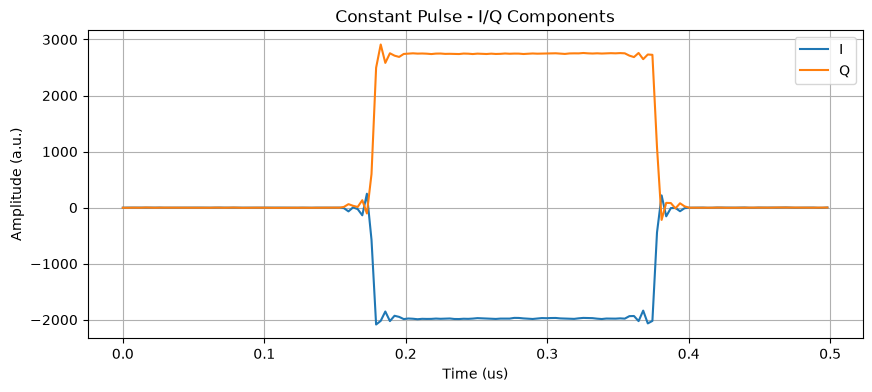

In [3]:
class ConstantPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Constant pulse - square shape
        self.add_pulse(
            ch=cfg['gen_ch'],
            name="const_pulse",
            style="const",
            freq=cfg['freq'],
            length=cfg['pulse_len'],
            phase=cfg['phase'],
            gain=cfg['gain']
        )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.pulse(ch=cfg['gen_ch'], name="const_pulse", t=0)

# Configure and run
config_const = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100.0,
    'pulse_len': 0.2,
    'phase': 0,
    'gain': 0.8,
    'trig_time': 0.25,
    'ro_len': 0.5
}

prog = ConstantPulseProgram(soccfg, reps=1, final_delay=1.0, cfg=config_const)

OUT = ARTIFACTS_ROOT / 'constant_pulse'
OUT.mkdir(parents=True, exist_ok=True)

# First simulation of the kernel session: build=True runs `make verilate`.
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used from here on.
soc = soc.prepare_emu(memdir=OUT, build=True)

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(10, 4))
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Constant Pulse - I/Q Components')
plt.grid(True)
plt.show()

**Observation:** The constant pulse produces a square-shaped response. The I and Q components oscillate at the carrier frequency (100 MHz in this case).

## 4. Shaped Pulses with Envelopes

Shaped pulses reduce spectral leakage and are essential for qubit control. The QICK supports:
- **Gaussian envelopes**: Smooth rise and fall
- **Flat-top pulses**: Gaussian edges with a constant top (ideal for readout resonators)

[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/shaped_pulse ...


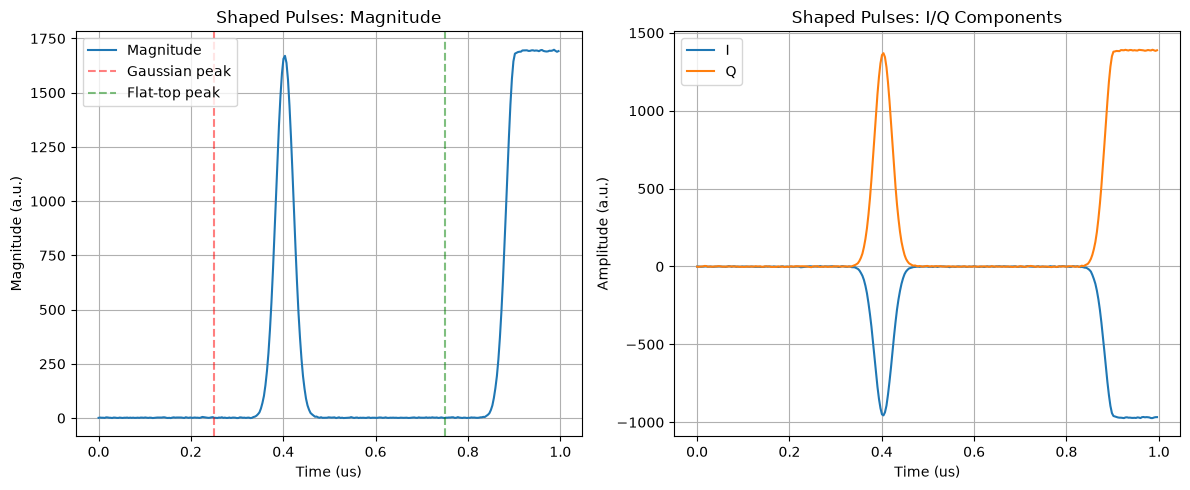

In [4]:
class ShapedPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a Gaussian envelope
        # The envelope length should be sufficient to capture the full pulse
        ramp_len = 0.15
        self.add_gauss(
            ch=cfg['gen_ch'],
            name="gauss_env",
            sigma=ramp_len / 8,  # Steepness of the Gaussian
            length=ramp_len,
            even_length=True
        )

        # Gaussian pulse (arbitrary envelope)
        self.add_pulse(
            ch=cfg['gen_ch'], name="gauss_pulse",
            style="arb", envelope="gauss_env",
            freq=cfg['freq'], phase=cfg['phase'], gain=cfg['gain']
        )

        # Flat-top pulse (good for readout)
        self.add_pulse(
            ch=cfg['gen_ch'], name="flattop_pulse",
            style="flat_top", envelope="gauss_env",
            freq=cfg['freq'], length=0.2, phase=cfg['phase'], gain=cfg['gain']
        )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator, kept for parity with hardware.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="gauss_pulse", t=0, tag='gauss')
        self.pulse(ch=cfg['gen_ch'], name="flattop_pulse", t=0.5, tag='flattop')

config_shaped = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100.0,
    'phase': 0,
    'gain': 0.8,
    'trig_time': 0.1,
    'ro_len': 1.0
}

prog = ShapedPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config_shaped)

OUT = ARTIFACTS_ROOT / 'shaped_pulse'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Separate the two pulses
magnitude = np.abs(iq_data[0].dot([1, 1j]))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_axis, magnitude, label='Magnitude')
plt.axvline(x=0.25, color='r', linestyle='--', alpha=0.5, label='Gaussian peak')
plt.axvline(x=0.75, color='g', linestyle='--', alpha=0.5, label='Flat-top peak')
plt.xlabel('Time (us)')
plt.ylabel('Magnitude (a.u.)')
plt.title('Shaped Pulses: Magnitude')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Shaped Pulses: I/Q Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Key points about shaped pulses:**
- Gaussian pulses minimize spectral sidebands, reducing crosstalk
- Flat-top pulses maintain constant amplitude at the top, ideal for readout resonators
- The envelope is applied to the pulse shape, not the carrier frequency

## 5. IQ Mixing and Quadrature Signals

The QICK uses IQ mixing to generate arbitrary phase shifts. I (in-phase) and Q (quadrature) components are 90 deg apart. By adjusting the phase parameter, you can rotate the pulse in the IQ plane.

[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/iq_mixing ...


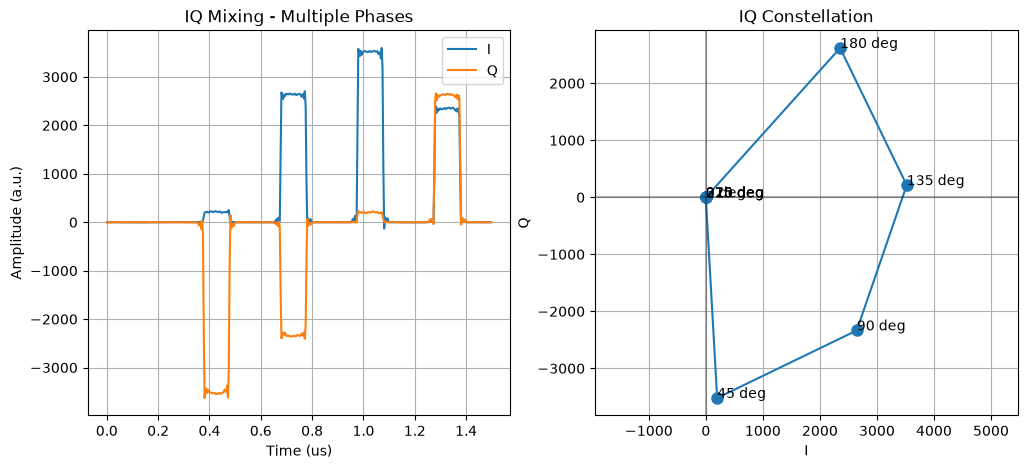

In [5]:
class IQMixingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Same pulse at different phases
        for phase in cfg['phases']:
            self.add_pulse(
                ch=cfg['gen_ch'],
                name=f"pulse_{phase}",
                style="const",
                freq=cfg['freq'],
                length=cfg['pulse_len'],
                phase=phase,
                gain=cfg['gain']
            )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator, kept for parity with hardware.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        for i, phase in enumerate(cfg['phases']):
            self.pulse(ch=cfg['gen_ch'], name=f"pulse_{phase}", t=i * 0.3)

config_iq = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 0.1,
    'gain': 0.8,
    'trig_time': 0.05,
    'ro_len': 1.5,
    'phases': [0, 45, 90, 135, 180, 225, 270, 315]
}

prog = IQMixingProgram(soccfg, reps=1, final_delay=0.5, cfg=config_iq)

OUT = ARTIFACTS_ROOT / 'iq_mixing'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Extract magnitude at each pulse center
pulse_centers = [0.15 + i * 0.3 for i in range(len(config_iq['phases']))]
idx_centers = [np.argmin(np.abs(time_axis - t)) for t in pulse_centers]
iq_at_centers = iq_data[0][idx_centers, :]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.xlabel('Time (us)')
plt.ylabel('Amplitude (a.u.)')
plt.title('IQ Mixing - Multiple Phases')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iq_at_centers[:,0], iq_at_centers[:,1], 'o-', markersize=8)
for i, phase in enumerate(config_iq['phases']):
    plt.annotate(f'{phase} deg', (iq_at_centers[i,0], iq_at_centers[i,1]))
plt.axhline(0, color='k', linestyle='-', alpha=0.3)
plt.axvline(0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ Constellation')
plt.axis('equal')
plt.grid(True)
plt.show()

**Explanation of IQ mixing:**
- Phase shifts rotate the pulse vector in the IQ plane
- A pulse with phase 0 deg appears on the I axis
- A pulse with phase 90 deg appears on the Q axis
- The constellation plot shows the relationship between I and Q for different phases

## 6. Readout Resonator Characterization

Readout resonators are used to measure qubit states. To optimize the readout, we need to find the resonator's resonant frequency. This is done by sweeping the readout frequency and measuring the response.

**Emulator note:** this section drives the sweep from a **Python** `for` loop -- a separate `acquire_decimated()` call (i.e. a separate Verilator run) per frequency point, unlike Sections 3-5 above where the whole sweep is compiled into one tProc program. Two adaptations:
- The on-hardware version uses `rounds=100` per point to average down measurement noise. The emulator is a deterministic simulation -- repeating an identical simulation 100 times returns the identical result, so `rounds=100` here would burn ~100x the wall-clock time for zero benefit. We use `rounds=1`.
- We shrink the frequency sweep from 41 points to 9 to keep total wall-clock time reasonable (roughly 41 Verilator runs vs. 9).

Sweeping readout frequency...
[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_sweep ...


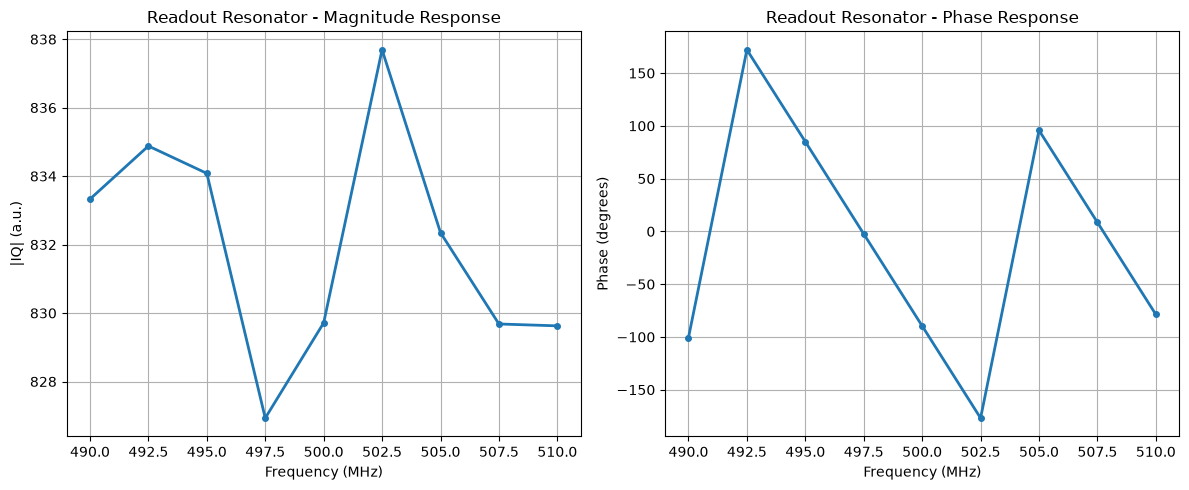


Resonance frequency: 497.50 MHz
Maximum magnitude: 826.932 a.u.


In [6]:
class ReadoutSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define the readout pulse (flat-top recommended for readout)
        ramp_len = 0.05
        self.add_gauss(ch=cfg['gen_ch'], name="ramp",
                       sigma=ramp_len/8, length=ramp_len, even_length=True)

        self.add_pulse(
            ch=cfg['gen_ch'], name="readout_pulse",
            style="flat_top", envelope="ramp",
            freq=cfg['freq'], length=cfg['pulse_len'], phase=0, gain=cfg['gain']
        )

        # Configure readout - freq will be swept
        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator, kept for parity with hardware.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="readout_pulse", t=0)

# Frequency sweep parameters
# HW version uses 41 points x rounds=100; shrunk for the emulator (see note above).
freqs = np.linspace(490, 510, 9)  # MHz
results_i = []
results_q = []

base_config = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'pulse_len': 0.5,
    'gain': 0.5,
    'trig_time': 0.1,
    'ro_len': 0.8
}

OUT = ARTIFACTS_ROOT / 'readout_sweep'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

print("Sweeping readout frequency...")
for f in freqs:
    config = base_config.copy()
    config['freq'] = f
    prog = ReadoutSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_data = prog.acquire_decimated(soc, rounds=1)  # deterministic sim -- see note above

    # Average the I/Q data over the pulse duration
    # (take mean after the pulse has settled)
    start_idx = int(0.2 / prog.get_time_axis(ro_index=0)[1])  # 0.2 us after trigger
    i_avg = np.mean(iq_data[0][start_idx:, 0])
    q_avg = np.mean(iq_data[0][start_idx:, 1])
    results_i.append(i_avg)
    results_q.append(q_avg)

results_mag = np.sqrt(np.array(results_i)**2 + np.array(results_q)**2)
results_phase = np.arctan2(results_q, results_i) * 180 / np.pi

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, results_mag, 'o-', linewidth=2, markersize=4)
plt.xlabel('Frequency (MHz)')
plt.ylabel('|IQ| (a.u.)')
plt.title('Readout Resonator - Magnitude Response')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freqs, results_phase, 'o-', linewidth=2, markersize=4)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Phase (degrees)')
plt.title('Readout Resonator - Phase Response')
plt.grid(True)
plt.tight_layout()
plt.show()

# Find the resonance frequency (minimum magnitude for a dispersive readout)
resonance_idx = np.argmin(results_mag)
resonance_freq = freqs[resonance_idx]
print(f"\nResonance frequency: {resonance_freq:.2f} MHz")
print(f"Maximum magnitude: {results_mag[resonance_idx]:.3f} a.u.")

**Interpreting the readout sweep:**
- The magnitude response shows a dip at the resonance frequency
- The phase response shows a sharp transition (dispersion) at resonance
- For optimal readout, you typically operate slightly detuned from resonance
- The exact optimal point depends on your measurement protocol (e.g., homodyne vs. heterodyne)
- **Emulator note:** the testbench's DAC/ADC loopback model doesn't include a real resonator's frequency-dependent response, so don't expect a sharp physical resonance dip here the way you would on hardware wired to an actual resonator -- the point of this section is to prove out the sweep-and-fit code pattern.

## 7. Optimizing Readout Parameters

Once you find the resonance frequency, you can optimize other parameters like readout length and gain.

**Emulator note:** same adaptation as Section 6 -- `rounds=1` (deterministic simulation) and a shrunk sweep (7 points instead of 19).

Optimizing readout length...
[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


[sim] Running simulation with EMU_DIR=../../artifacts/06_generators_and_readouts/readout_optimization ...


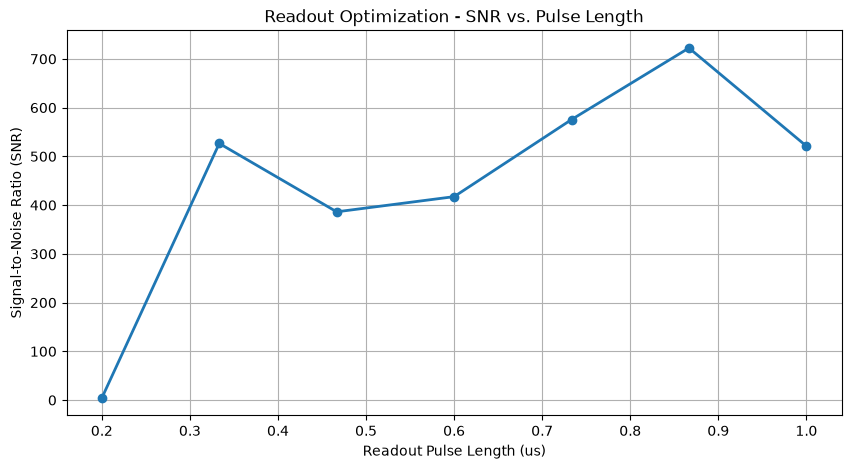


Optimal readout length: 0.87 us
Maximum SNR: 722.4


In [7]:
class ReadoutOptimizationProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        ramp_len = 0.05
        self.add_gauss(ch=cfg['gen_ch'], name="ramp",
                       sigma=ramp_len/8, length=ramp_len, even_length=True)

        self.add_pulse(
            ch=cfg['gen_ch'], name="readout_pulse",
            style="flat_top", envelope="ramp",
            freq=cfg['freq'], length=cfg['pulse_len'], phase=0, gain=cfg['gain']
        )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # NB: ddr4=True is a no-op in the emulator, kept for parity with hardware.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="readout_pulse", t=0)

# Use the found resonance frequency
optimal_freq = resonance_freq if 'resonance_freq' in dir() else 500.0

# Sweep readout length
# HW version uses 19 points x rounds=100; shrunk for the emulator (see note above).
lengths = np.linspace(0.2, 1.0, 7)
snr_results = []

OUT = ARTIFACTS_ROOT / 'readout_optimization'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

print("Optimizing readout length...")
for l in lengths:
    config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'freq': optimal_freq,
        'pulse_len': l,
        'gain': 0.5,
        'trig_time': 0.1,
        'ro_len': l + 0.1  # Readout slightly longer than pulse
    }
    prog = ReadoutOptimizationProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_data = prog.acquire_decimated(soc, rounds=1)  # deterministic sim -- see note above

    # Estimate SNR from signal magnitude
    signal_mag = np.abs(iq_data[0].dot([1, 1j]))
    signal_peak = np.max(signal_mag)
    noise_std = np.std(signal_mag[:50])  # Noise before the pulse
    snr = signal_peak / noise_std if noise_std > 0 else 0
    snr_results.append(snr)

plt.figure(figsize=(10, 5))
plt.plot(lengths, snr_results, 'o-', linewidth=2, markersize=6)
plt.xlabel('Readout Pulse Length (us)')
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.title('Readout Optimization - SNR vs. Pulse Length')
plt.grid(True)
plt.show()

optimal_idx = np.argmax(snr_results)
optimal_length = lengths[optimal_idx]
print(f"\nOptimal readout length: {optimal_length:.2f} us")
print(f"Maximum SNR: {snr_results[optimal_idx]:.1f}")

## 8. Summary

You have learned:
- How to configure generators with different pulse styles (constant, Gaussian, flat-top)
- How IQ mixing works and how phase shifts affect the IQ plane
- How to characterize a readout resonator via frequency sweeps
- How to optimize readout parameters like pulse length
- Why `rounds` should stay at 1 for Python-loop sweeps on the emulator (the simulation is deterministic, so extra rounds don't reduce noise)

**Key takeaways:**
- Use shaped pulses (Gaussian or flat-top) for better spectral purity
- IQ mixing allows arbitrary phase control of your pulses
- Readout resonators should be characterized before experiments (on real hardware; the emulator's simplified DAC/ADC loopback doesn't model a resonator's frequency response)
- The optimal readout frequency is often slightly detuned from resonance
- For Python-loop sweeps, keep `rounds=1` and the point count small -- each point is a full Verilator run

**Next steps:** Proceed to [`07_Advanced_Generators_And_Readouts_emu.ipynb`](./07_Advanced_Generators_And_Readouts_emu.ipynb) to learn about the different generator/readout types in more depth.